## Importancia por Permutación (Aprendizaje de Máquina Interpretable)
### Cargar y describir el conjunto de datos "Diabetes"
Referencia: https://www.youtube.com/watch?v=puC9emuHWqA&list=PLat2DtY8K7YUp76hCJlkz0v2yeSTNSbU6

In [ ]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(scaled=False)
print(diabetes["DESCR"]) # Descripcion del dataset

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [2]:
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

In [8]:
print(diabetes.data)

[[59.      2.     32.1    ...  4.      4.8598 87.    ]
 [48.      1.     21.6    ...  3.      3.8918 69.    ]
 [72.      2.     30.5    ...  4.      4.6728 85.    ]
 ...
 [60.      2.     24.9    ...  3.77    4.1271 95.    ]
 [36.      1.     30.     ...  4.79    5.1299 85.    ]
 [36.      1.     19.6    ...  3.      4.5951 92.    ]]


### Selección de variables independientes y variable objetivo

In [10]:
# Nota: Variables y sus indíces
# 0:age, 1:sex, 2:bmi, 3:bp, 4:s1, 5:s2, 6:s3, 7:s4, 8:s5, 9:s6]

# Selección de variables ad-hoc para fines de explicación
nombre_variables = ["Edad", "Género", "IMC", "Presión arterial", "Colesterol"]
X = diabetes.data[:, [0, 1, 2, 3, 7]]

# Nivel de azúcar en sangre (s6) variable objetivo
y = diabetes.data[:, 9]

### Crea conjuntos de Entrenamiento y Prueba

In [11]:
from sklearn.model_selection import train_test_split

X_entrena, X_prueba, y_entrena, y_prueba = \
            train_test_split(X, y, test_size=0.3, random_state=42)

### Preprocesar/Estandarizar los datos

In [12]:
from sklearn.preprocessing import StandardScaler

# Estandarizar lso datos usando Z-score 
X_entrena = StandardScaler().fit_transform(X_entrena)
y_entrena = StandardScaler().fit_transform(y_entrena.reshape(-1, 1))
X_prueba = StandardScaler().fit_transform(X_prueba)
y_prueba = StandardScaler().fit_transform(y_prueba.reshape(-1, 1))

### Define y entrena al Perceptrón Multicapa (MLP)

In [13]:
from sklearn.neural_network import MLPRegressor

# Se creó un MLP con valores por defecto para fines de explicación
mlp = MLPRegressor(random_state=42, max_iter=1000)
mlp.fit(X_entrena, y_entrena)

d:\Machine_Learning_Projects\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1775: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Machine_Learning_Projects\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


### Importancia de Características por Permutación

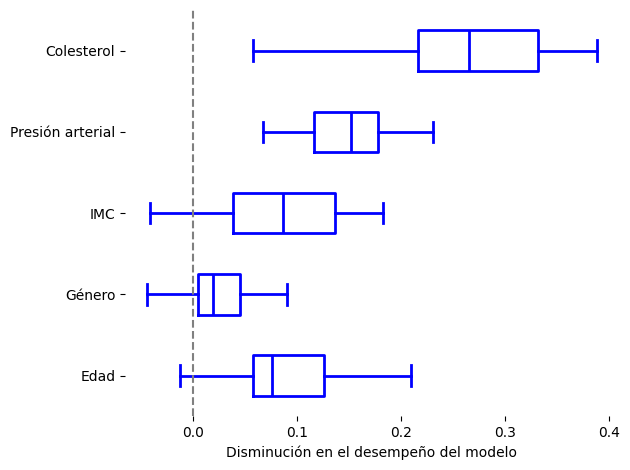

In [17]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Calcula la Importancia de Características por Permutación
resultado = permutation_importance(mlp, X_prueba, y_prueba, \
                                   n_repeats=30, random_state=42)

# Crea un DataFrame para visualización de la importancia
importancias = pd.DataFrame(
    resultado.importances.T,
    columns = nombre_variables,
)

ax = importancias.plot.box(vert=False)

ax.set_xlabel("Disminución en el desempeño del modelo")
ax.figure.tight_layout()

# Detalles de la personalización de la visualización
for i, artist in enumerate(ax.artists):
    artist.set_edgecolor("blue")
    artist.set_linewidth(2)

for i, line in enumerate(ax.lines):
    line.set_color("blue")
    line.set_linewidth(2)

# Quitar marco
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Incluir una línea en x = 0 para tener referencia de si mejoró o empeoró
ax.axvline(x=0, color="gray", linestyle="--")

plt.show()